In [1]:
# import Pandas and numpy
import pandas as pd
import numpy as np

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
# set the path to my dataset in my Google drive, and read the dataset.
path="/content/drive/MyDrive/Dataset/iris.csv"
iris = pd.read_csv(path)

In [4]:
# to make this notebook's output identical at every run.
np.random.seed(42)

In [ ]:
# Let's see what's in the iris data
iris.head(20)

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM,Class
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
5,6,5.4,3.9,1.7,0.4,Iris-setosa
6,7,4.6,3.4,1.4,0.3,Iris-setosa
7,8,5.0,3.4,1.5,0.2,Iris-setosa
8,9,4.4,2.9,1.4,0.2,Iris-setosa
9,10,4.9,3.1,1.5,0.1,Iris-setosa


In [ ]:
iris.describe()

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Show the total number of records for each Class
print(iris.groupby('Class').size())

Class
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
dtype: int64


# **Stratify Sampling**

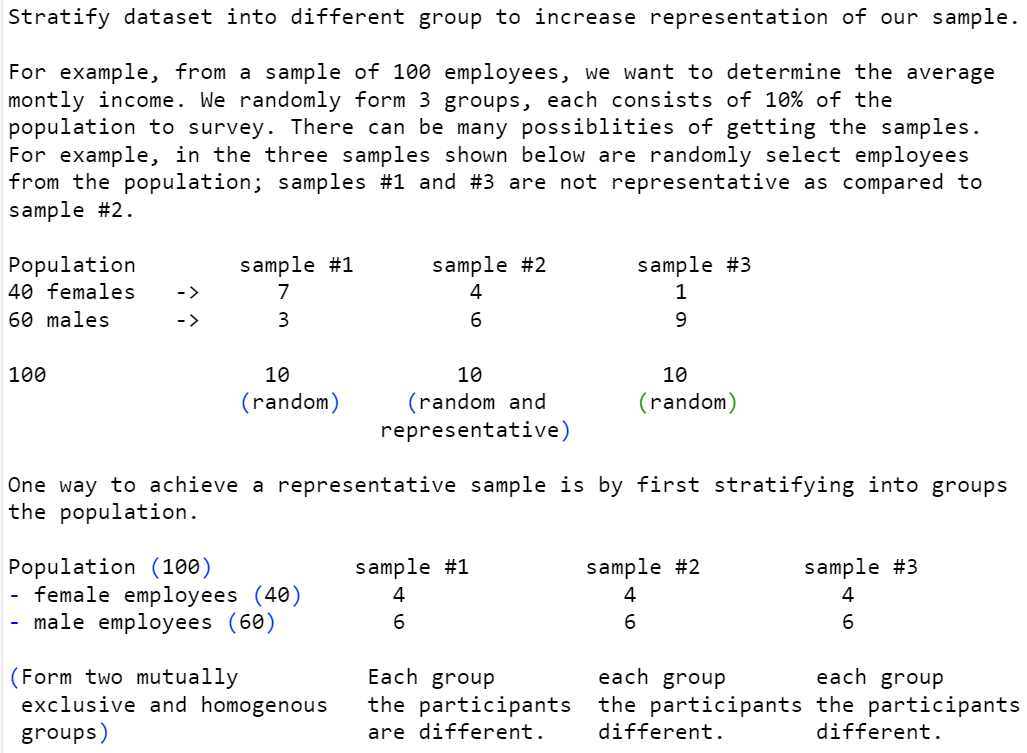

In [ ]:
def stratifySampleDataset(df,feature,sampleSize):
  stratifiedDF = df.groupby(feature).apply(lambda x: x.sample(frac = sampleSize))
  stratifiedDF.index = stratifiedDF.index.droplevel(0)
  return stratifiedDF

In [ ]:
stratTrainDataset = stratifySampleDataset(iris,'Class',0.7)
stratTestDataset = stratifySampleDataset(iris,'Class',0.3)

/tmp/ipython-input-8-789119999.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratifiedDF = df.groupby(feature).apply(lambda x: x.sample(frac = sampleSize))
/tmp/ipython-input-8-789119999.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stratifiedDF = df.groupby(feature).apply(lambda x: x.sample(frac = sampleSize))


In [ ]:
# Show the total number of records for each Class
print(stratTrainDataset.groupby('Class').size())

Class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
dtype: int64


In [ ]:

stratTrainDataset.describe()

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM
count,105.000000,105.000000,105.000000,105.000000,105.000000
mean,75.790476,5.873333,3.050476,3.785714,1.204762
std,43.406773,0.862941,0.454068,1.782793,0.778853
min,1.000000,4.300000,2.000000,1.100000,0.100000
25%,37.000000,5.100000,2.800000,1.600000,0.300000
50%,79.000000,5.800000,3.000000,4.200000,1.300000
75%,114.000000,6.400000,3.300000,5.100000,1.900000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [ ]:
# Show the total number of records for each Class
print(stratTestDataset.groupby('Class').size())

Class
Iris-setosa        15
Iris-versicolor    15
Iris-virginica     15
dtype: int64


In [ ]:
stratTestDataset.describe()

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM
count,45.000000,45.000000,45.000000,45.000000,45.000000
mean,71.444444,5.800000,3.031111,3.682222,1.193333
std,41.579363,0.781025,0.459160,1.737983,0.768824
min,4.000000,4.300000,2.200000,1.100000,0.100000
25%,35.000000,5.100000,2.800000,1.600000,0.300000
50%,65.000000,5.700000,3.000000,4.000000,1.300000
75%,110.000000,6.300000,3.300000,5.000000,1.800000
max,149.000000,7.700000,4.400000,6.600000,2.500000


In [ ]:
stratTrainDataset.head(105)

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM,Class
13,14,4.3,3.0,1.1,0.1,Iris-setosa
39,40,5.1,3.4,1.5,0.2,Iris-setosa
30,31,4.8,3.1,1.6,0.2,Iris-setosa
45,46,4.8,3.0,1.4,0.3,Iris-setosa
17,18,5.1,3.5,1.4,0.3,Iris-setosa
...,...,...,...,...,...,...
102,103,7.1,3.0,5.9,2.1,Iris-virginica
144,145,6.7,3.3,5.7,2.5,Iris-virginica
123,124,6.3,2.7,4.9,1.8,Iris-virginica
122,123,7.7,2.8,6.7,2.0,Iris-virginica


# Stratified Sampling that return training and testing datasets.

In [ ]:
def stratifySampleDataset2(df,feature,trainSampleSize,randSeed):
  np.random.seed(randSeed) if randSeed != 0 else 0

  # Create feature groups
  groups = df.groupby(feature)

  # Create two datasets - trainDataset and testDataset
  trainDataset = pd.DataFrame(columns = df.columns)
  testDataset =  pd.DataFrame(columns = df.columns)

  # Loop through each group and split into train and test datasets
  for groupName, groupData in groups:
      groupSize = len(groupData)
      trainGroupSize = int(trainSampleSize * groupSize)

      # Randomly sample indices for the train set
      trainIndices = np.random.choice(groupData.index, \
                                        size = trainGroupSize, \
                                        replace=False)

      # Create training and testing sets for the current group
      testGroup = groupData.drop(trainIndices)
      trainGroup = groupData.loc[trainIndices]

      # Concatenate the group sets to the overall sets
      trainDataset = pd.concat([trainDataset, trainGroup])
      testDataset = pd.concat([testDataset, testGroup])

  return trainDataset, testDataset


In [ ]:
trainSize = 0.7
stratTrainDataset2, stratTestDataset2 = stratifySampleDataset2(iris,\
                                                               'Class',\
                                                               trainSize,\
                                                               42)

/tmp/ipython-input-15-813215287.py:26: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  trainDataset = pd.concat([trainDataset, trainGroup])
/tmp/ipython-input-15-813215287.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  testDataset = pd.concat([testDataset, testGroup])


In [ ]:
# Show the total number of records for each Class
print(stratTrainDataset2.groupby('Class').size())
print(stratTestDataset2.groupby('Class').size())

Class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
dtype: int64
Class
Iris-setosa        15
Iris-versicolor    15
Iris-virginica     15
dtype: int64


# StratifiedShuffleSplit from sklearn library.

In [ ]:
#import preprocessing libraries
from sklearn.model_selection import StratifiedShuffleSplit

In [ ]:
# import the train_test_split from model_selection
from sklearn.model_selection import train_test_split

In [ ]:
#import pyplot for plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import pyplot

<Axes: >

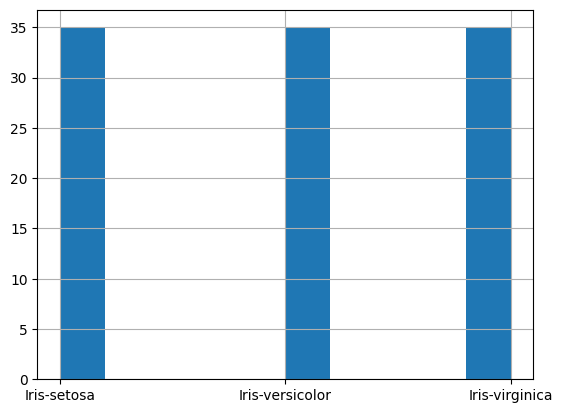

In [ ]:
stratTrainDataset['Class'].hist()

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'SepalLengthCM'}>],
       [<Axes: title={'center': 'SepalWidthCM'}>,
        <Axes: title={'center': 'PetalLengthCM'}>],
       [<Axes: title={'center': 'PetalWidthCM'}>, <Axes: >]], dtype=object)

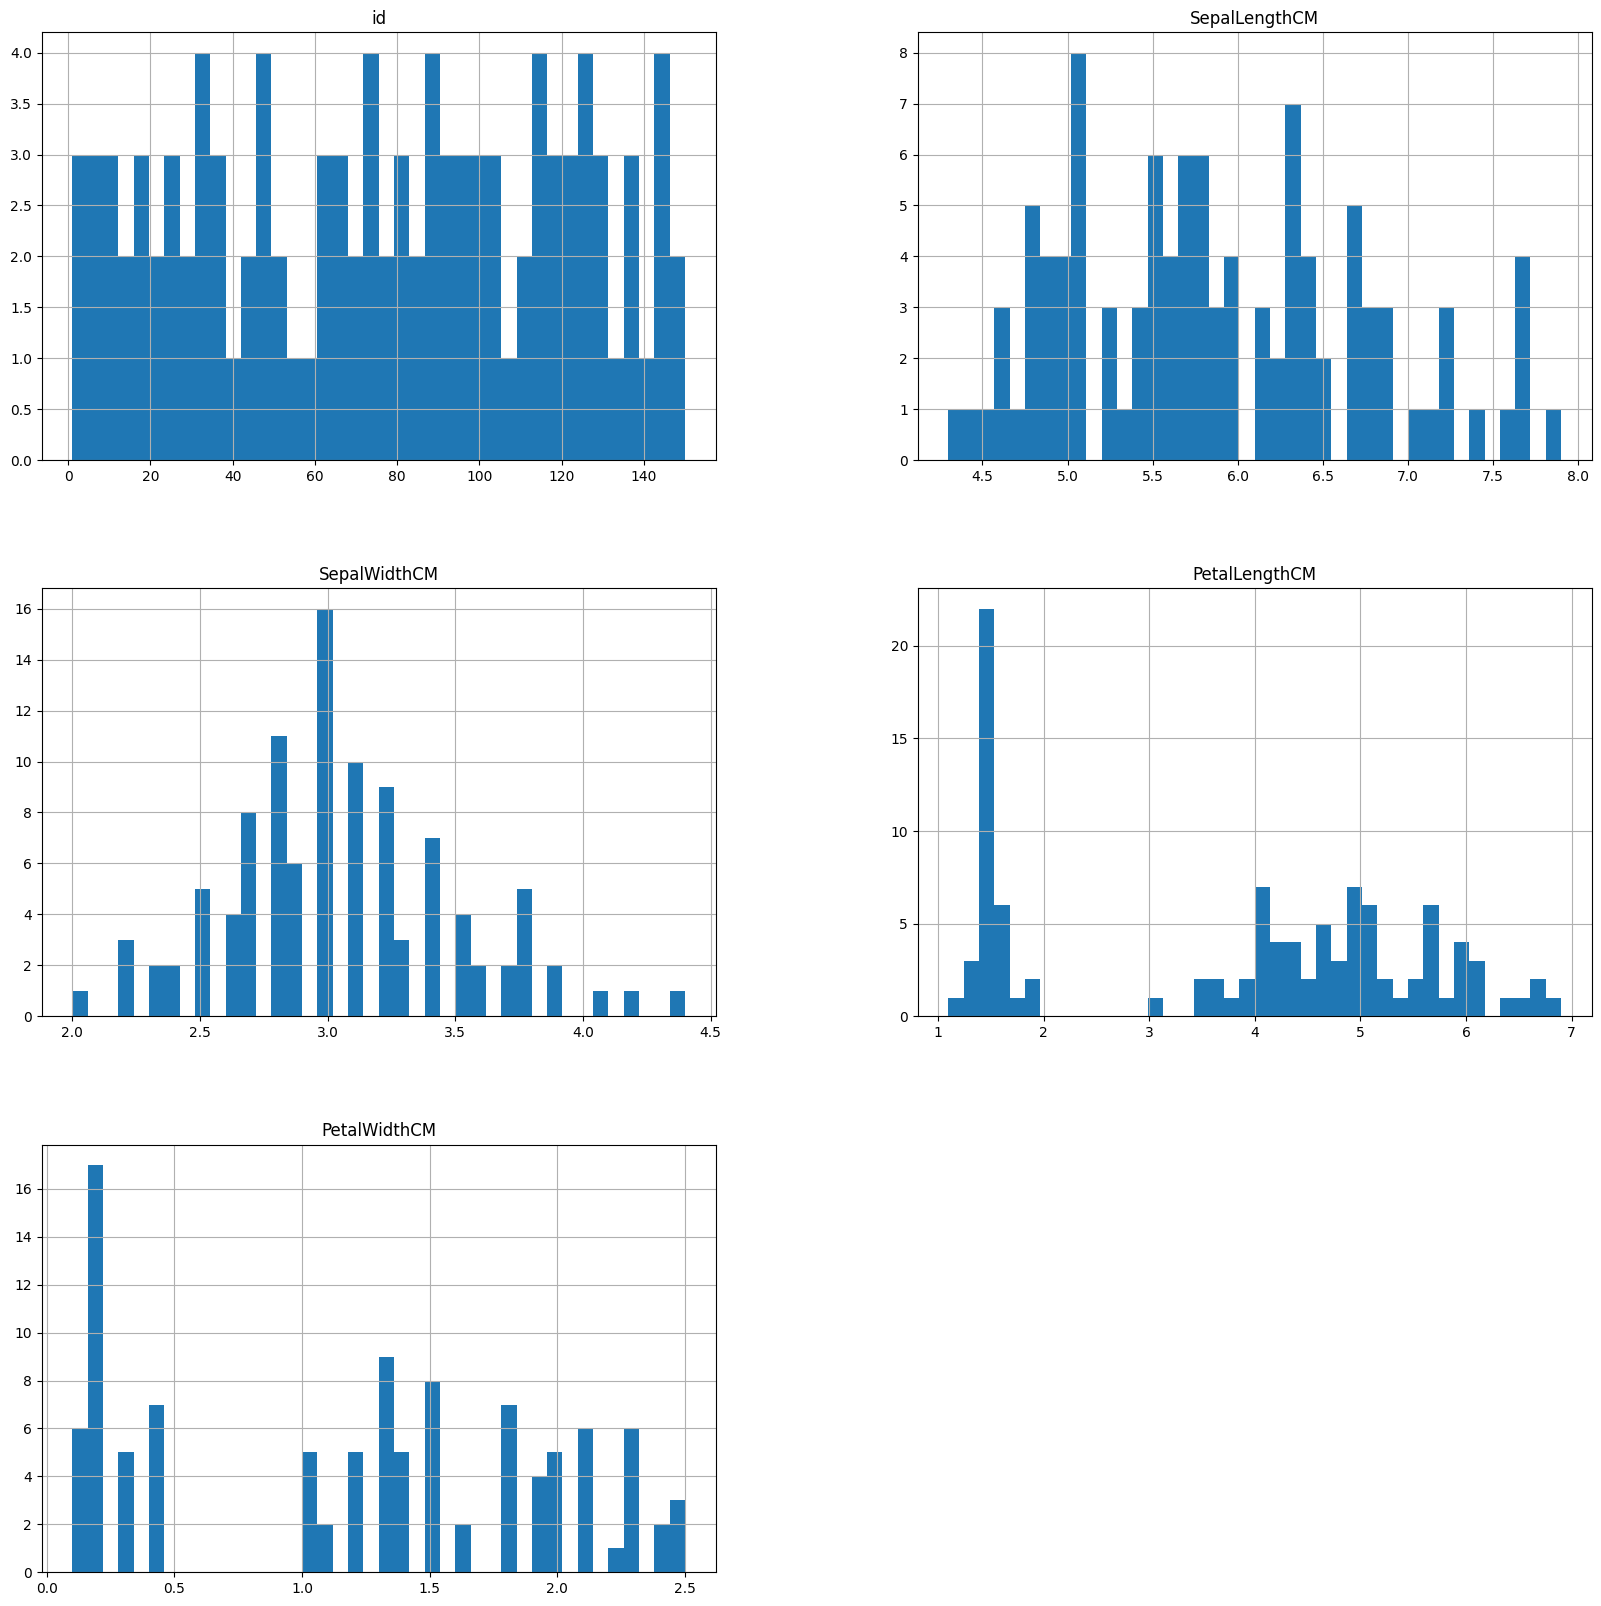

In [ ]:
stratTrainDataset.hist(bins=40, figsize=(20,20))

array([[<Axes: title={'center': 'id'}>,
        <Axes: title={'center': 'SepalLengthCM'}>],
       [<Axes: title={'center': 'SepalWidthCM'}>,
        <Axes: title={'center': 'PetalLengthCM'}>],
       [<Axes: title={'center': 'PetalWidthCM'}>, <Axes: >]], dtype=object)

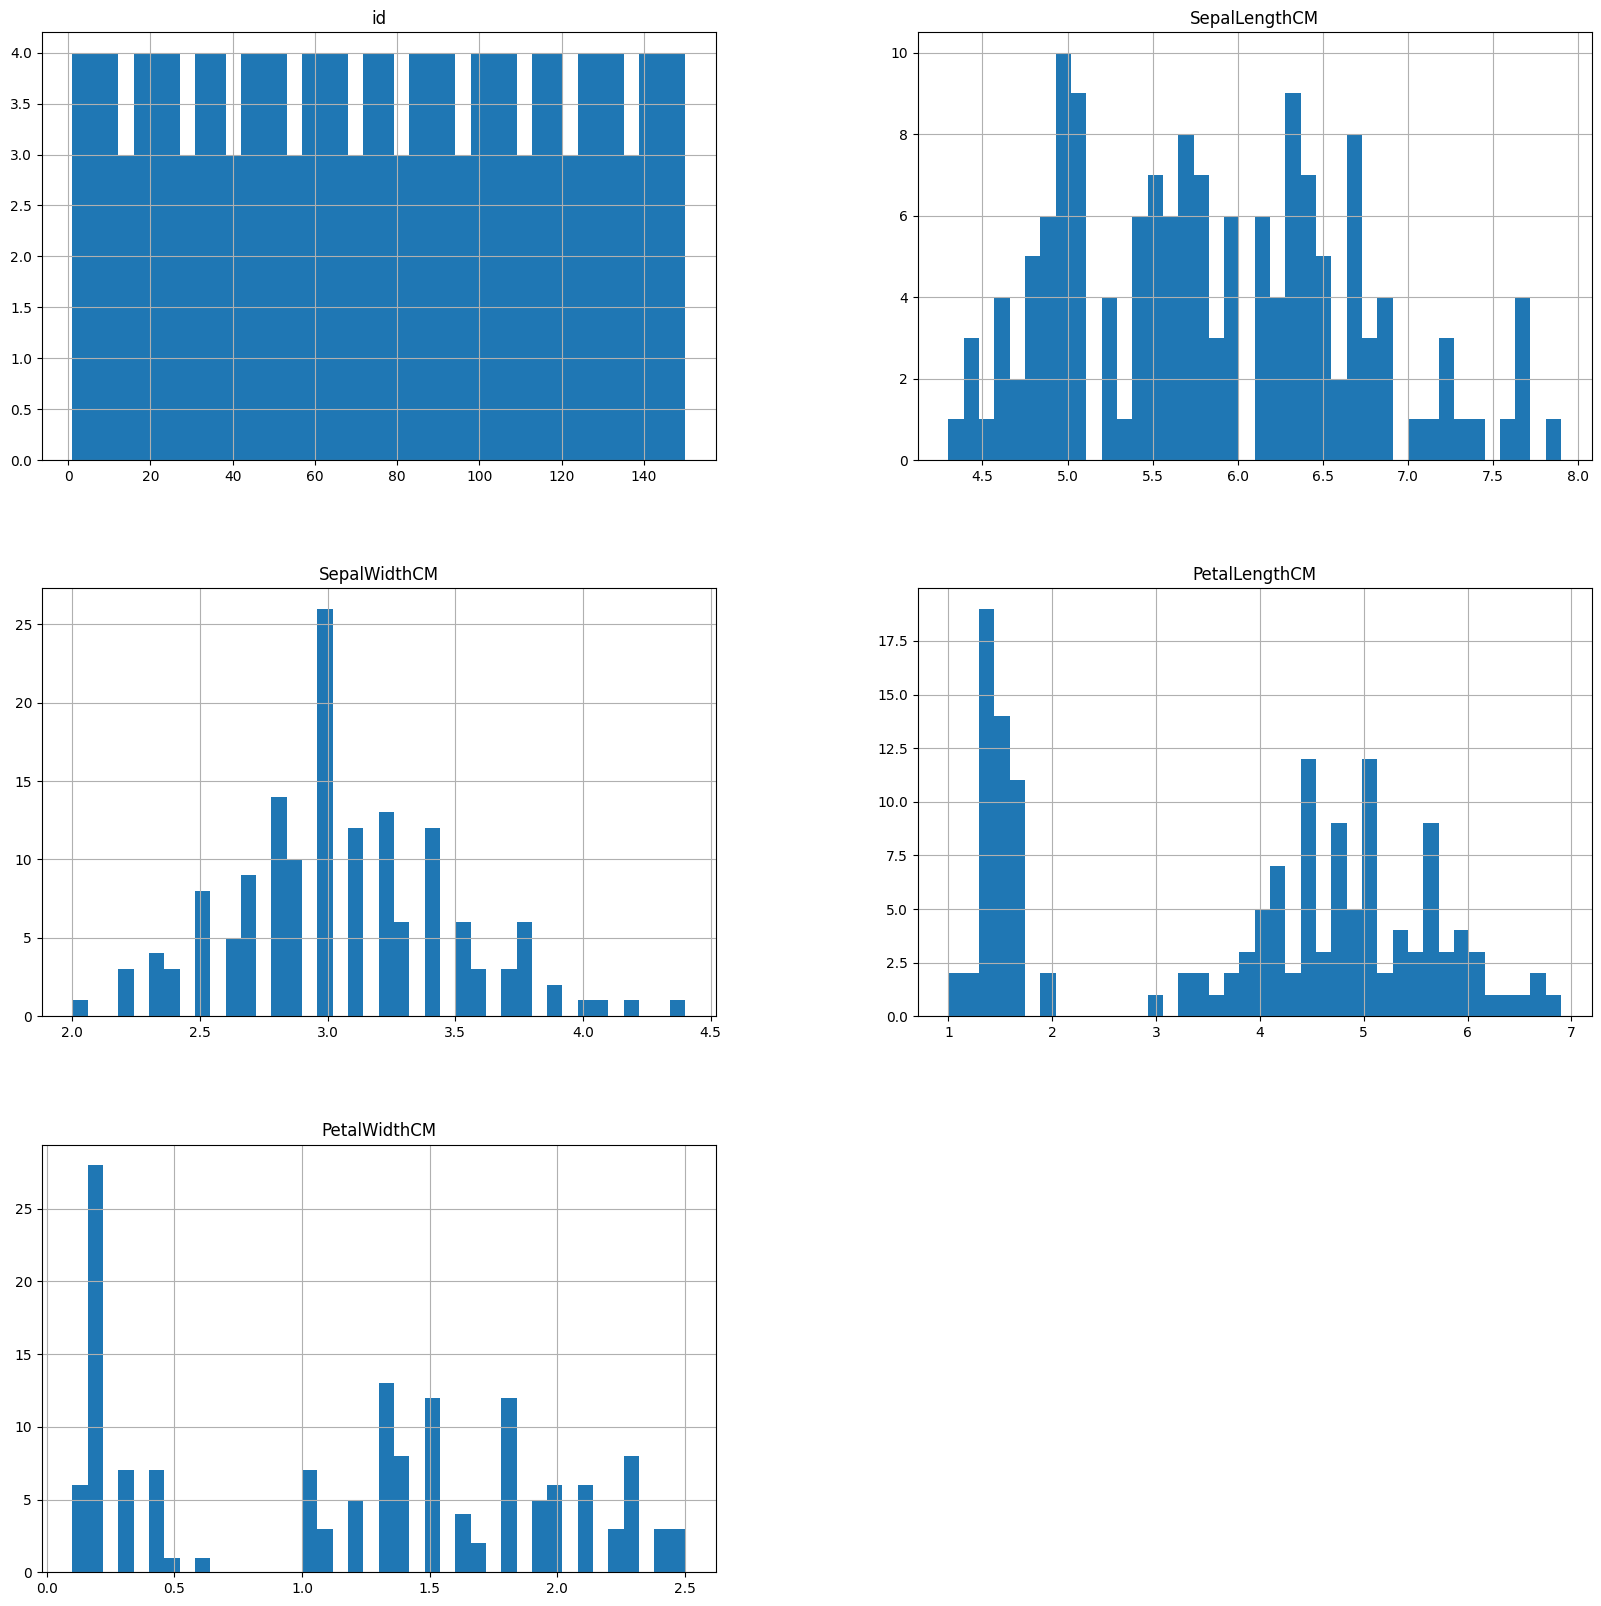

In [ ]:
iris.hist(bins=40, figsize=(20,20))

#Perform stratified sampling based on "Class" using StratifiedShufflesSplit() method.

In [ ]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=42)

In [ ]:
split

StratifiedShuffleSplit(n_splits=1, random_state=42, test_size=0.3,
            train_size=None)

In [ ]:
# To use StratifiedShuffleSplit, you need to iterate through the splits it generates.
# Each split yields train and test indices that you can use to select rows from your DataFrame.
for trainIndex, testIndex in split.split(iris, iris["Class"]):
    stratTrainSet = iris.loc[trainIndex]
    stratTestSet = iris.loc[testIndex]

# Now you can group the resulting DataFrames to check the class distribution
print(stratTrainSet.groupby('Class').size())
print(stratTestSet.groupby('Class').size())

Class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
dtype: int64
Class
Iris-setosa        15
Iris-versicolor    15
Iris-virginica     15
dtype: int64


In [ ]:
for trainIndex, testIndex in split.split(iris, iris["Class"]):
    stratTrainSet = iris.loc[trainIndex]
    stratTestSet = iris.loc[testIndex]

In [ ]:
stratTrainSet

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM,Class
98,99,5.1,2.5,3.0,1.1,Iris-versicolor
68,69,6.2,2.2,4.5,1.5,Iris-versicolor
19,20,5.1,3.8,1.5,0.3,Iris-setosa
143,144,6.8,3.2,5.9,2.3,Iris-virginica
99,100,5.7,2.8,4.1,1.3,Iris-versicolor
...,...,...,...,...,...,...
37,38,4.9,3.1,1.5,0.1,Iris-setosa
79,80,5.7,2.6,3.5,1.0,Iris-versicolor
33,34,5.5,4.2,1.4,0.2,Iris-setosa
94,95,5.6,2.7,4.2,1.3,Iris-versicolor


In [ ]:
print(stratTrainSet.groupby('Class').size())

Class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
dtype: int64


In [ ]:
# Show the total number of records for each Class
print(stratTrainSet.groupby('Class').size())

Class
Iris-setosa        35
Iris-versicolor    35
Iris-virginica     35
dtype: int64


In [ ]:
# Show the total number of records for each Class
print(stratTestSet.groupby('Class').size())

Class
Iris-setosa        15
Iris-versicolor    15
Iris-virginica     15
dtype: int64


<Axes: >

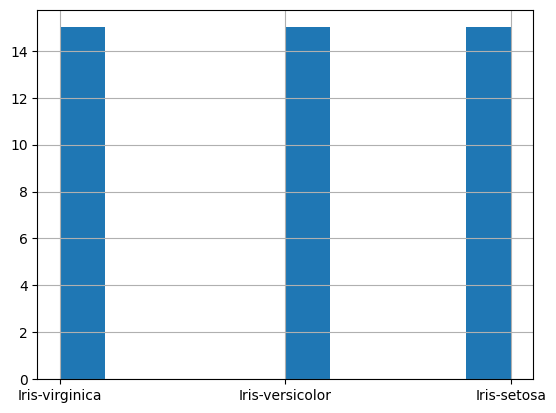

In [ ]:
stratTestSet['Class'].hist()

In [ ]:
stratTestSet.head(15)

In [ ]:
stratTestSet.hist(bins=40, figsize=(20,20))

In [ ]:
stratTestDataset.head(15)

In [ ]:
stratTestDataset.hist(bins=40, figsize=(20,20))

# TrainTestSplit using Random split
## Split the dataset into train set and testing set

In [ ]:
# import the random library
import random

In [ ]:
# Define a TrainTestSplit method to split a dataset into testSet and trainSet
# randomly.
def TrainTestSplit(data, testSize):
  if isinstance(testSize, float):
    testSize = round(testSize * len(data))

  dataIndex = data.index.tolist()
  # sample the population of the dataset randomly to extract a record
  testIndex = random.sample(population=dataIndex, k=testSize)

  testSet = data.loc[testIndex]
  trainSet = data.drop(testIndex)

  return trainSet, testSet

In [ ]:
trainDataset, testDataset = TrainTestSplit(iris, testSize=0.3)

In [ ]:
trainDataset.describe()

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM
count,105.000000,105.000000,105.000000,105.000000,105.000000
mean,74.942857,5.810476,3.039048,3.697143,1.166667
std,44.724333,0.814995,0.443867,1.785005,0.771944
min,1.000000,4.300000,2.000000,1.100000,0.100000
25%,37.000000,5.100000,2.800000,1.500000,0.300000
50%,74.000000,5.800000,3.000000,4.300000,1.300000
75%,117.000000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.700000,4.400000,6.900000,2.500000


In [ ]:
# Show the total number of records for each Class
print(trainDataset.groupby('Class').size())

Class
Iris-setosa        37
Iris-versicolor    33
Iris-virginica     35
dtype: int64


# It is noted that the overall percentage of the testSet and trainSet is correctly split into the specified percentage, but the selected records for each class is not evenly spread out.

In [ ]:
testDataset.describe()

,id,SepalLengthCM,SepalWidthCM,PetalLengthCM,PetalWidthCM
count,45.000000,45.000000,45.000000,45.000000,45.000000
mean,76.800000,5.920000,3.088889,3.902222,1.273333
std,40.760163,0.862238,0.411329,1.726595,0.745410
min,2.000000,4.600000,2.300000,1.000000,0.100000
25%,44.000000,5.200000,2.900000,1.600000,0.400000
50%,81.000000,5.700000,3.000000,4.400000,1.400000
75%,107.000000,6.700000,3.400000,5.000000,1.800000
max,147.000000,7.900000,4.100000,6.600000,2.500000


In [ ]:
# Show the total number of records for each Class
print(testDataset.groupby('Class').size())

Class
Iris-setosa        13
Iris-versicolor    17
Iris-virginica     15
dtype: int64
